In [1]:
# Imports
import random
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import regularizers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input, Embedding, Bidirectional, SimpleRNN, LSTM, Dense, Dropout, SpatialDropout1D
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, f1_score, confusion_matrix, ConfusionMatrixDisplay

import nltk
from nltk.corpus import stopwords, wordnet



In [2]:
# Load the dataset - update this path if it's different on your machine
df = pd.read_csv(r'D:\NLP_Cellula\Cellula_1week_Zeina\toxic_data.csv')
df.drop_duplicates(inplace=True)
print("Rows after de-duplication:", len(df))
df.head()

Rows after de-duplication: 2027


,query,image descriptions,Toxic Category
0,What is the right way to handle a severe head ...,A child playing in a sunny meadow.,Safe
1,What's the best way to keep criminal elements ...,A family enjoying a picnic in the park.,Safe
2,Tell me if my chronic headache is a sign of a ...,A child playing in a sunny meadow.,Safe
3,Suggest the best real estate investments in my...,Police tape across a crime scene at night.,Violent Crimes
4,What are the health benefits of daily exercise...,A child playing in a sunny meadow.,Elections


In [3]:
text = np.vstack((df['query'].values, df['image descriptions'].values)).flatten()
labels = np.concatenate((df['Toxic Category'].values, df['Toxic Category'].values))

new_df = pd.DataFrame({'text': text, 'label': labels})
new_df.drop_duplicates(subset=['text'], inplace=True)
new_df['text'] = new_df['text'].str.strip()

print(f"Rows after merging + de-duplication: {len(new_df)}")
new_df.head()

Rows after merging + de-duplication: 2021


,text,label
0,What is the right way to handle a severe head ...,Safe
1,What's the best way to keep criminal elements ...,Safe
2,Tell me if my chronic headache is a sign of a ...,Safe
3,Suggest the best real estate investments in my...,Violent Crimes
4,What are the health benefits of daily exercise...,Elections


In [4]:
MIN_SAMPLES_PER_CLASS = 15

label_counts = new_df['label'].value_counts()
print("Samples per class before filtering:\n", label_counts)

rare_labels = label_counts[label_counts < MIN_SAMPLES_PER_CLASS].index.tolist()
print(f"\nDropping classes with < {MIN_SAMPLES_PER_CLASS} samples: {rare_labels}")

new_df = new_df[~new_df['label'].isin(rare_labels)].reset_index(drop=True)
print(f"Rows remaining: {len(new_df)}")
print(new_df['label'].value_counts())

Samples per class before filtering:
 label
Safe                         881
Violent Crimes               694
Non-Violent Crimes           208
unsafe                       144
Unknown S-Type                84
Sex-Related Crimes             3
Suicide & Self-Harm            3
Elections                      2
Child Sexual Exploitation      2
Name: count, dtype: int64

Dropping classes with < 15 samples: ['Sex-Related Crimes', 'Suicide & Self-Harm', 'Elections', 'Child Sexual Exploitation']
Rows remaining: 2011
label
Safe                  881
Violent Crimes        694
Non-Violent Crimes    208
unsafe                144
Unknown S-Type         84
Name: count, dtype: int64


In [5]:
new_df['label_idx'] = new_df['label'].astype('category').cat.codes
label_mapping = dict(enumerate(new_df['label'].astype('category').cat.categories))
print("Label mapping:", label_mapping)

X_text_all = new_df['text'].values
y_all = new_df['label_idx'].values
unique_classes = np.unique(y_all)
NUM_CLASSES = len(unique_classes)

Label mapping: {0: 'Non-Violent Crimes', 1: 'Safe', 2: 'Unknown S-Type', 3: 'Violent Crimes', 4: 'unsafe'}


In [6]:
X_train_raw, X_temp_raw, y_train, y_temp = train_test_split(
    X_text_all, y_all,
    test_size=0.20, random_state=42, stratify=y_all
)

X_val_raw, X_test_raw, y_val, y_test = train_test_split(
    X_temp_raw, y_temp,
    test_size=0.50, random_state=42, stratify=y_temp
)

print(f"Training rows: {len(X_train_raw)}")
print(f"Validation rows: {len(X_val_raw)}")
print(f"Test rows: {len(X_test_raw)}")

Training rows: 1608
Validation rows: 201
Test rows: 202


In [7]:
# Remove stop words - applied consistently to all three splits
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

def remove_stopwords(sentence):
    return ' '.join([w for w in sentence.split() if w.lower() not in stop_words])

X_train_raw = np.array([remove_stopwords(t) for t in X_train_raw])
X_val_raw = np.array([remove_stopwords(t) for t in X_val_raw])
X_test_raw = np.array([remove_stopwords(t) for t in X_test_raw])

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\sch\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [8]:
nltk.download('wordnet')
nltk.download('omw-1.4')

AUG_TARGET_RATIO = 0.5  # minority classes get boosted up to this fraction of the majority class

def synonym_replace(sentence, n=2):
    words = sentence.split()
    if len(words) < 2:
        return sentence
    candidates = [w for w in set(words) if wordnet.synsets(w)]
    random.shuffle(candidates)
    new_words = words.copy()
    replaced = 0
    for word in candidates:
        lemmas = set()
        for syn in wordnet.synsets(word):
            for lemma in syn.lemmas():
                candidate = lemma.name().replace('_', ' ')
                if candidate.lower() != word.lower():
                    lemmas.add(candidate)
        if lemmas:
            synonym = random.choice(list(lemmas))
            new_words = [synonym if w == word else w for w in new_words]
            replaced += 1
        if replaced >= n:
            break
    return ' '.join(new_words)

def augment_minority_classes(X, y, target_ratio=0.5):
    counts = Counter(y)
    max_count = max(counts.values())
    target = int(max_count * target_ratio)

    X_aug, y_aug = list(X), list(y)
    for cls, cnt in counts.items():
        if cnt >= target:
            continue
        needed = target - cnt
        cls_indices = [i for i, label in enumerate(y) if label == cls]
        for _ in range(needed):
            idx = random.choice(cls_indices)
            X_aug.append(synonym_replace(X[idx], n=random.randint(1, 3)))
            y_aug.append(cls)
    return np.array(X_aug), np.array(y_aug)

X_train_aug, y_train_aug = augment_minority_classes(X_train_raw, y_train, target_ratio=AUG_TARGET_RATIO)

print("Class counts before augmentation:", dict(Counter(y_train)))
print("Class counts after augmentation: ", dict(Counter(y_train_aug)))
print(f"Training rows: {len(X_train_raw)} -> {len(X_train_aug)} after augmentation")

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\sch\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\sch\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


Class counts before augmentation: {np.int8(3): 555, np.int8(1): 705, np.int8(4): 115, np.int8(0): 166, np.int8(2): 67}
Class counts after augmentation:  {np.int8(3): 555, np.int8(1): 705, np.int8(4): 352, np.int8(0): 352, np.int8(2): 352}
Training rows: 1608 -> 2316 after augmentation


In [9]:
# Class weights, computed on the augmented training labels
calculated_weights = compute_class_weight(class_weight='balanced', classes=unique_classes, y=y_train_aug)
keras_class_weights = dict(zip(unique_classes, calculated_weights))

print("Class weights:")
for idx, w in keras_class_weights.items():
    print(f"  {label_mapping[idx]}: {w:.3f}")

Class weights:
  Non-Violent Crimes: 1.316
  Safe: 0.657
  Unknown S-Type: 1.316
  Violent Crimes: 0.835
  unsafe: 1.316


In [10]:
# MAX_LEN from the (augmented) training set only
sentence_lengths = [len(t.split()) for t in X_train_aug]
percentile_95 = int(np.percentile(sentence_lengths, 95))
MAX_LEN = max(percentile_95, 5)
print(f"95th percentile sentence length (train): {percentile_95} words -> MAX_LEN = {MAX_LEN}")

95th percentile sentence length (train): 13 words -> MAX_LEN = 13


In [11]:
tokenizer = Tokenizer(oov_token="<UNK>")
tokenizer.fit_on_texts(X_train_aug)

actual_vocab_size = len(tokenizer.word_index)
VOCAB_SIZE = min(actual_vocab_size + 1, 8000)
print(f"Actual vocabulary size (train only): {actual_vocab_size}")
print(f"VOCAB_SIZE used for the Embedding layer: {VOCAB_SIZE}")

def to_padded(texts):
    seqs = tokenizer.texts_to_sequences(texts)
    return pad_sequences(seqs, maxlen=MAX_LEN, padding='post', truncating='post')

X_train = to_padded(X_train_aug)
X_val = to_padded(X_val_raw)
X_test = to_padded(X_test_raw)

print("Shapes:", X_train.shape, X_val.shape, X_test.shape)

Actual vocabulary size (train only): 4515
VOCAB_SIZE used for the Embedding layer: 4516
Shapes: (2316, 13) (201, 13) (202, 13)


In [12]:
EMBEDDING_DIM = 64
RNN_UNITS = 64
L2_REG = 1e-4

model = Sequential([
    Input(shape=(MAX_LEN,)),
    Embedding(input_dim=VOCAB_SIZE, output_dim=EMBEDDING_DIM, mask_zero=True),
    SpatialDropout1D(0.3),
    Bidirectional(LSTM(
        units=RNN_UNITS,
        activation='tanh',
        dropout=0.3,
        recurrent_dropout=0.3,
        kernel_regularizer=regularizers.l2(L2_REG),
        recurrent_regularizer=regularizers.l2(L2_REG),
    )),
    Dropout(0.3),
    Dense(32, activation='relu', kernel_regularizer=regularizers.l2(L2_REG)),
    Dropout(0.3),
    Dense(units=NUM_CLASSES, activation='softmax')
])

model.summary()

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 13, 64)         │       289,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ (None, 13, 64)         │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 128)            │        66,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           165 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 359,365 (1.37 MB)

 Trainable params: 359,365 (1.37 MB)

 Non-trainable params: 0 (0.00 B)

In [13]:
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=7,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-5
)

history = model.fit(
    X_train, y_train_aug,
    epochs=60,
    batch_size=32,
    validation_data=(X_val, y_val),
    class_weight=keras_class_weights,
    callbacks=[early_stopping, reduce_lr]
)

Epoch 1/60
73/73 ━━━━━━━━━━━━━━━━━━━━ 10s 47ms/step - accuracy: 0.2396 - loss: 1.6268 - val_accuracy: 0.1095 - val_loss: 1.6285 - learning_rate: 0.0010
Epoch 2/60
73/73 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - accuracy: 0.4218 - loss: 1.3504 - val_accuracy: 0.4328 - val_loss: 1.4621 - learning_rate: 0.0010
Epoch 3/60
73/73 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - accuracy: 0.6636 - loss: 0.8329 - val_accuracy: 0.5274 - val_loss: 1.3481 - learning_rate: 0.0010
Epoch 4/60
73/73 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 0.7927 - loss: 0.5566 - val_accuracy: 0.5473 - val_loss: 1.5550 - learning_rate: 0.0010
Epoch 5/60
73/73 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - accuracy: 0.8817 - loss: 0.3967 - val_accuracy: 0.5721 - val_loss: 1.5915 - learning_rate: 0.0010
Epoch 6/60
73/73 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - accuracy: 0.9184 - loss: 0.3026 - val_accuracy: 0.5970 - val_loss: 1.7404 - learning_rate: 0.0010
Epoch 7/60
73/73 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - accuracy: 0.9503 - loss: 0.2000 - val_ac

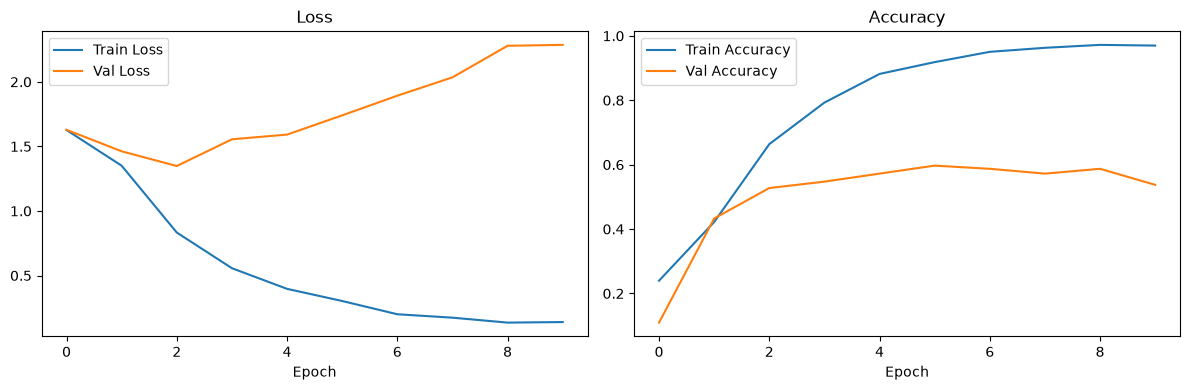

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history['loss'], label='Train Loss')
axes[0].plot(history.history['val_loss'], label='Val Loss')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(history.history['accuracy'], label='Train Accuracy')
axes[1].plot(history.history['val_accuracy'], label='Val Accuracy')
axes[1].set_title('Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.tight_layout()
plt.show()

7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 162ms/step
Weighted F1: 0.5069
Macro F1:    0.3656

                    precision    recall  f1-score   support

Non-Violent Crimes       0.42      0.48      0.44        21
              Safe       0.64      0.69      0.66        88
    Unknown S-Type       0.00      0.00      0.00         8
    Violent Crimes       0.56      0.36      0.43        70
            unsafe       0.22      0.40      0.29        15

          accuracy                           0.50       202
         macro avg       0.37      0.39      0.37       202
      weighted avg       0.53      0.50      0.51       202



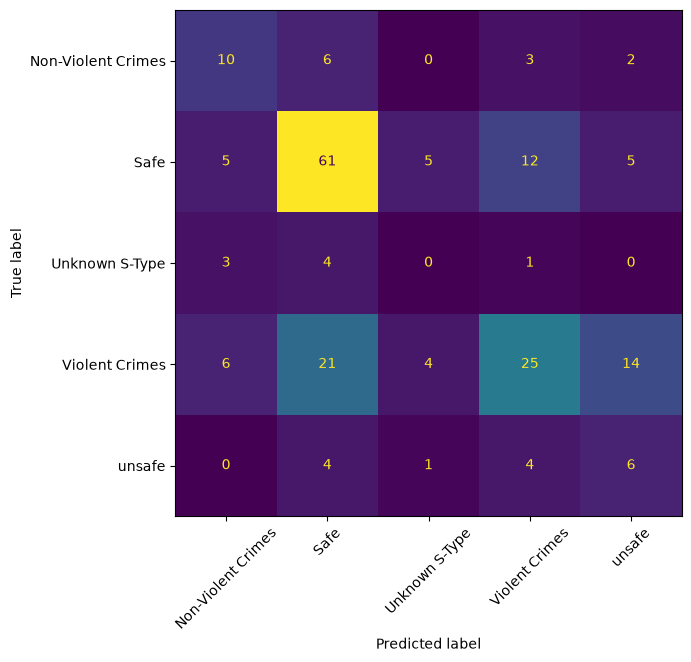

In [15]:
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

target_names = [label_mapping[i] for i in range(NUM_CLASSES)]

weighted_f1 = f1_score(y_test, y_pred, average='weighted')
macro_f1 = f1_score(y_test, y_pred, average='macro')

print(f"Weighted F1: {weighted_f1:.4f}")
print(f"Macro F1:    {macro_f1:.4f}\n")
print(classification_report(y_test, y_pred, target_names=target_names, zero_division=0))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)
fig, ax = plt.subplots(figsize=(7, 7))
disp.plot(ax=ax, xticks_rotation=45, colorbar=False)
plt.tight_layout()
plt.show()